# Dataset Inspection

Set `DATA_PATH` below and run all. Handles `.csv`, `.tsv`, `.parquet`, `.json`, `.jsonl`, `.xlsx`.

Install if needed: `pip install pandas pyarrow matplotlib openpyxl`

In [1]:
DATA_PATH = "Motor_Vehicle_Collisions_-_Crashes_20260815.csv"
NROWS = None   # e.g. 100_000 to sample big files fast
TARGET = None  # optional label column name

In [2]:
import os
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


def load(path, nrows=None):
    ext = os.path.splitext(path)[1].lower()
    if ext in (".csv", ".txt", ".tsv", ".tab"):
        sep = "\t" if ext in (".tsv", ".tab") else ","
        if nrows is None:
            try:  # pyarrow engine: multithreaded, much faster on big files
                return pd.read_csv(path, sep=sep, engine="pyarrow")
            except ImportError:
                pass
        return pd.read_csv(path, sep=sep, nrows=nrows, low_memory=False)
    if ext in (".parquet", ".pq"):
        df = pd.read_parquet(path)
        return df.head(nrows) if nrows else df
    if ext == ".jsonl":
        return pd.read_json(path, lines=True, nrows=nrows)
    if ext == ".json":
        df = pd.read_json(path)
        return df.head(nrows) if nrows else df
    if ext in (".xlsx", ".xls"):
        return pd.read_excel(path, nrows=nrows)
    raise ValueError(f"Unsupported extension: {ext}")


df = load(DATA_PATH, NROWS)
print(f"file  : {os.path.getsize(DATA_PATH) / 1e6:.0f} MB on disk")
print(f"shape : {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"memory: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB")
df.head()

file  : 567 MB on disk
shape : 2,269,187 rows x 29 cols
memory: 2066 MB


,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,None,None,NaN,NaN,None,WHITESTONE EXPRESSWAY,20 AVENUE,None,2.0,0.0,0,0,0,0,2,0,Aggressive Driving/Road Rage,Unspecified,None,None,None,4455765,Sedan,Sedan,None,None,None
1,03/26/2022,11:45,None,None,NaN,NaN,None,QUEENSBORO BRIDGE UPPER,None,None,1.0,0.0,0,0,0,0,1,0,Pavement Slippery,None,None,None,None,4513547,Sedan,None,None,None,None
2,11/01/2023,1:29,BROOKLYN,11230,40.62179,-73.970024,"(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,None,1.0,0.0,0,0,0,0,1,0,Unspecified,Unspecified,Unspecified,None,None,4675373,Moped,Sedan,Sedan,None,None
3,06/29/2022,6:55,None,None,NaN,NaN,None,THROGS NECK BRIDGE,None,None,0.0,0.0,0,0,0,0,0,0,Following Too Closely,Unspecified,None,None,None,4541903,Sedan,Pick-up Truck,None,None,None
4,09/21/2022,13:21,None,None,NaN,NaN,None,BROOKLYN BRIDGE,None,None,0.0,0.0,0,0,0,0,0,0,Passing Too Closely,Unspecified,None,None,None,4566131,Station Wagon/Sport Utility Vehicle,None,None,None,None


## Column overview

In [3]:
n = len(df)
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "null_pct": (df.isna().sum() / n * 100).round(2),
    "n_unique": df.nunique(dropna=True),
    "unique_pct": (df.nunique(dropna=True) / n * 100).round(2),
    "sample": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
})
overview.sort_values("null_pct", ascending=False)

,dtype,non_null,null_pct,n_unique,unique_pct,sample
VEHICLE TYPE CODE 5,object,9988,99.56,81,0.00,Station Wagon/Sport Utility Vehicle
CONTRIBUTING FACTOR VEHICLE 5,object,10314,99.55,34,0.00,Unspecified
VEHICLE TYPE CODE 4,object,36244,98.40,125,0.01,Station Wagon/Sport Utility Vehicle
CONTRIBUTING FACTOR VEHICLE 4,object,37633,98.34,43,0.00,Unspecified
VEHICLE TYPE CODE 3,object,157830,93.04,315,0.01,Sedan
CONTRIBUTING FACTOR VEHICLE 3,object,164389,92.76,56,0.00,Unspecified
OFF STREET NAME,object,406805,82.07,271300,11.96,61 Ed Koch queensborough bridge
CROSS STREET NAME,object,1398952,38.35,25403,1.12,20 AVENUE
ZIP CODE,object,1577526,30.48,236,0.01,11230
BOROUGH,object,1577812,30.47,5,0.00,BROOKLYN


In [4]:
# Red flags
const_cols = overview.index[overview["n_unique"] <= 1].tolist()
id_like = overview.index[(overview["unique_pct"] > 99) & (overview["dtype"] != "float64")].tolist()
empty_cols = overview.index[overview["null_pct"] == 100].tolist()
dupes = df.duplicated().sum()

print(f"duplicate rows : {dupes:,} ({dupes / n * 100:.2f}%)")
print(f"constant cols  : {const_cols}")
print(f"all-null cols  : {empty_cols}")
print(f"id-like cols   : {id_like}")

duplicate rows : 0 (0.00%)
constant cols  : []
all-null cols  : []
id-like cols   : ['COLLISION_ID']


## Numeric columns

In [5]:
num = df.select_dtypes(include=np.number)
cat = df.select_dtypes(include=["object", "category", "bool"])
print(f"{num.shape[1]} numeric, {cat.shape[1]} categorical/text")
num.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T if num.shape[1] else "no numeric columns"

11 numeric, 18 categorical/text


,count,mean,std,min,1%,25%,50%,75%,99%,max
LATITUDE,2028381.0,4.057145e+01,2.487895e+00,0.00000,40.546208,4.066724e+01,4.072016e+01,4.076963e+01,4.088859e+01,4.334444e+01
LONGITUDE,2028381.0,-7.364972e+01,4.609250e+00,-201.35999,-74.168300,-7.397446e+01,-7.392653e+01,-7.386636e+01,-7.372700e+01,0.000000e+00
NUMBER OF PERSONS INJURED,2269169.0,3.333172e-01,7.187101e-01,0.00000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00,4.300000e+01
NUMBER OF PERSONS KILLED,2260274.0,1.600248e-03,4.221063e-02,0.00000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.000000e+00
NUMBER OF PEDESTRIANS INJURED,2269187.0,6.073497e-02,2.521715e-01,0.00000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.700000e+01
NUMBER OF PEDESTRIANS KILLED,2269187.0,7.954391e-04,2.882608e-02,0.00000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00
NUMBER OF CYCLIST INJURED,2269187.0,2.967406e-02,1.720208e-01,0.00000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,4.000000e+00
NUMBER OF CYCLIST KILLED,2269187.0,1.295618e-04,1.142044e-02,0.00000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00
NUMBER OF MOTORIST INJURED,2269187.0,2.380707e-01,6.799336e-01,0.00000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00,4.300000e+01
NUMBER OF MOTORIST KILLED,2269187.0,6.460464e-04,2.776300e-02,0.00000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00


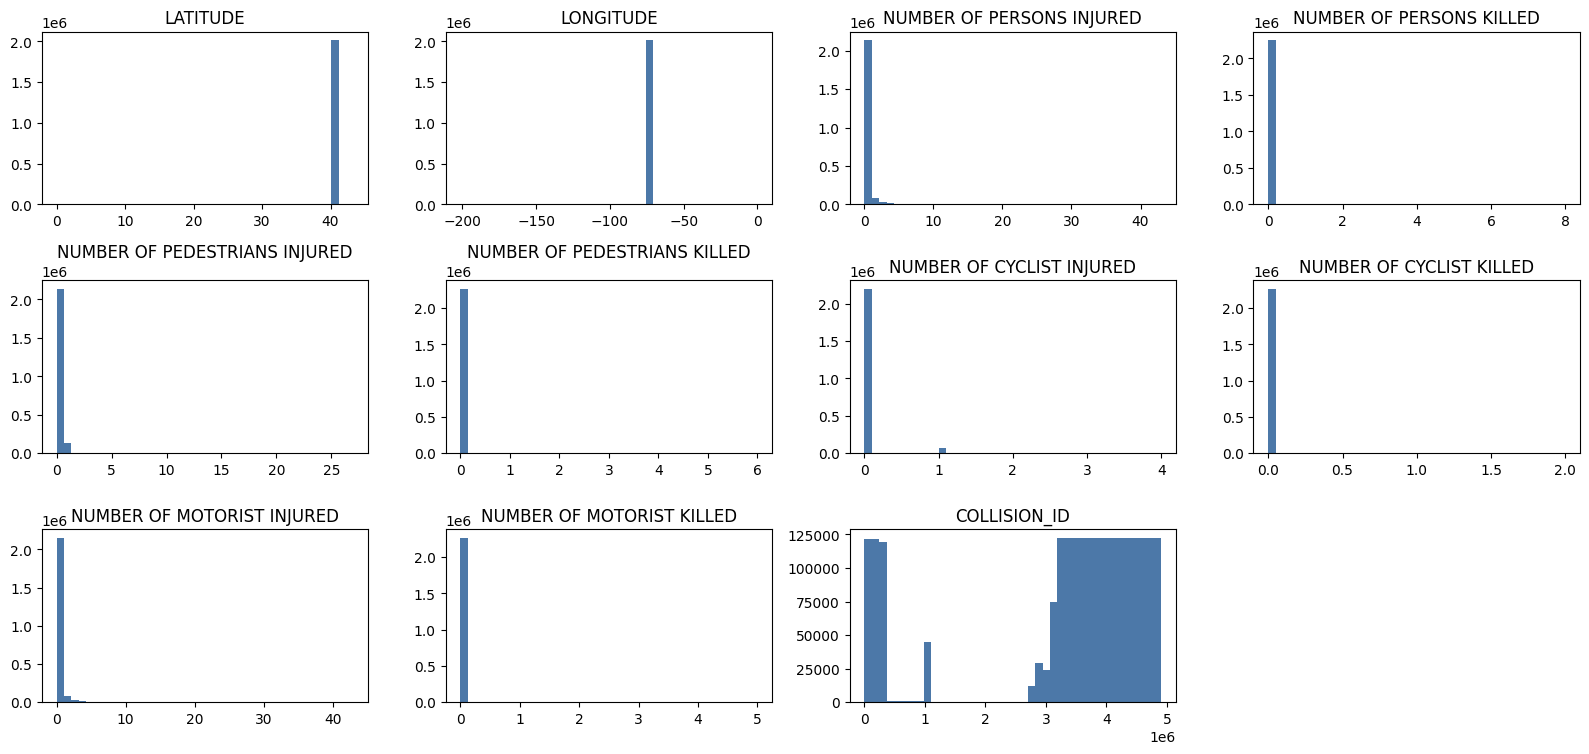

In [6]:
import matplotlib.pyplot as plt

cols = num.columns[:16]
if len(cols):
    ncols = 4
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.6 * nrows))
    for ax, c in zip(np.ravel(axes), cols):
        df[c].plot.hist(bins=40, ax=ax, title=c, color="#4C78A8")
        ax.set_ylabel("")
    for ax in np.ravel(axes)[len(cols):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Categorical columns

In [7]:
for c in cat.columns:
    vc = df[c].value_counts(dropna=False)
    print(f"\n=== {c}  ({len(vc):,} unique) ===")
    print(vc.head(10).to_string())


=== CRASH DATE  (5,094 unique) ===
CRASH DATE
01/21/2014    1161
11/15/2018    1065
12/15/2017     999
05/19/2017     974
01/18/2015     961
02/03/2014     960
03/06/2015     939
05/18/2017     911
01/07/2017     896
03/02/2018     884

=== CRASH TIME  (1,440 unique) ===
CRASH TIME
16:00    30135
15:00    29682
17:00    29594
18:00    27397
14:00    27163
13:00    25261
0:00     24566
9:00     23084
12:00    22959
19:00    22914

=== BOROUGH  (6 unique) ===
BOROUGH
None             691375
BROOKLYN         506806
QUEENS           422409
MANHATTAN        348485
BRONX            234088
STATEN ISLAND     66024

=== ZIP CODE  (237 unique) ===
ZIP CODE
None     691661
11207     31169
11236     21562
11101     21013
11203     20426
11234     19889
11385     19762
11208     19530
11212     19388
11201     19151

=== LOCATION  (397,986 unique) ===
LOCATION
None                         240806
    (0.0, 0.0)                 5825
(0.0, 0.0)                     1766
(40.608757, -74.038086)        

## Correlations

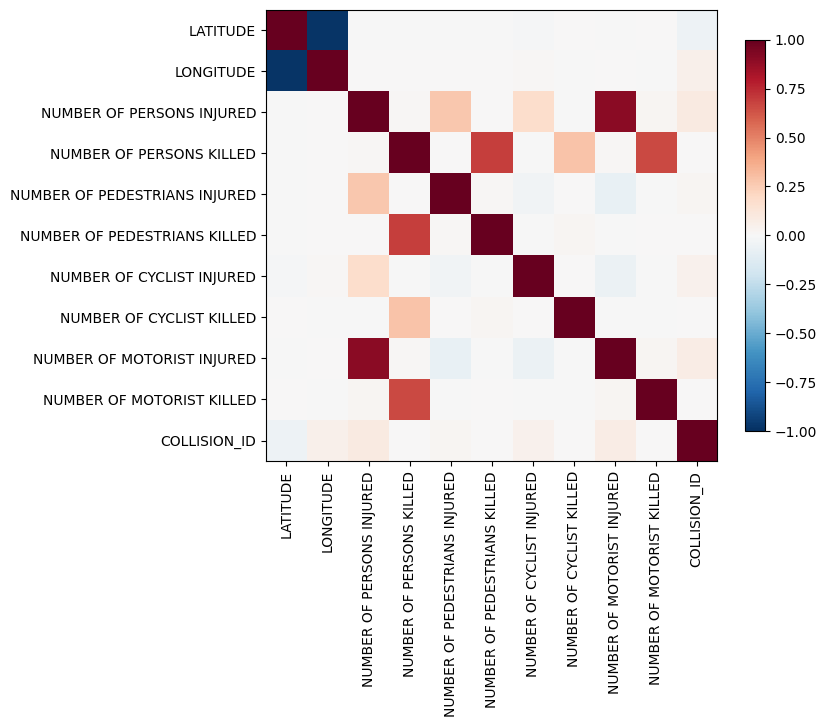

top |correlations|:
LATITUDE                       LONGITUDE                       -0.978650
NUMBER OF PERSONS INJURED      NUMBER OF MOTORIST INJURED       0.903500
NUMBER OF PERSONS KILLED       NUMBER OF PEDESTRIANS KILLED     0.690651
                               NUMBER OF MOTORIST KILLED        0.657931
                               NUMBER OF CYCLIST KILLED         0.282209
NUMBER OF PERSONS INJURED      NUMBER OF PEDESTRIANS INJURED    0.271700
                               NUMBER OF CYCLIST INJURED        0.172058
                               COLLISION_ID                     0.091590
NUMBER OF MOTORIST INJURED     COLLISION_ID                     0.073540
NUMBER OF PEDESTRIANS INJURED  NUMBER OF MOTORIST INJURED      -0.073204


In [8]:
if num.shape[1] > 1:
    corr = num.corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(0.5 * len(corr) + 3, 0.5 * len(corr) + 2))
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr)), corr.columns, rotation=90)
    ax.set_yticks(range(len(corr)), corr.columns)
    fig.colorbar(im, shrink=0.8)
    plt.tight_layout()
    plt.show()

    pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
    print("top |correlations|:")
    print(pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(10).to_string())

## Target (optional)

In [9]:
if TARGET and TARGET in df.columns:
    y = df[TARGET]
    if y.nunique() <= 20:
        print(y.value_counts(dropna=False).to_string())
        print("\nproportions:")
        print((y.value_counts(normalize=True) * 100).round(2).to_string())
    else:
        print(y.describe().to_string())
        if pd.api.types.is_numeric_dtype(y):
            print("\ncorrelation with numeric features:")
            print(num.corrwith(y).drop(TARGET, errors="ignore").sort_values(key=abs, ascending=False).head(15).to_string())
else:
    print("TARGET not set")

TARGET not set


## NYC collisions: time, place, severity

In [10]:
ts = pd.to_datetime(
    df["CRASH DATE"] + " " + df["CRASH TIME"], format="%m/%d/%Y %H:%M"
)
df["dt"] = ts
df["year"] = ts.dt.year
df["hour"] = ts.dt.hour
df["dow"] = ts.dt.dayofweek  # 0 = Monday

print(f"date range: {ts.min()}  ->  {ts.max()}")

inj = [c for c in df.columns if c.startswith("NUMBER OF") and c.endswith("INJURED")]
kil = [c for c in df.columns if c.startswith("NUMBER OF") and c.endswith("KILLED")]
print("\ntotals:")
print(df[inj + kil].sum().astype("int64").to_string())
print(f"\ncrashes with >=1 injury: {(df['NUMBER OF PERSONS INJURED'] > 0).mean() * 100:.1f}%")
print(f"crashes with >=1 death : {(df['NUMBER OF PERSONS KILLED'] > 0).mean() * 100:.2f}%")

date range: 2012-07-01 00:05:00  ->  2026-06-11 13:08:00

totals:
NUMBER OF PERSONS INJURED        756353
NUMBER OF PEDESTRIANS INJURED    137819
NUMBER OF CYCLIST INJURED         67336
NUMBER OF MOTORIST INJURED       540227
NUMBER OF PERSONS KILLED           3617
NUMBER OF PEDESTRIANS KILLED       1805
NUMBER OF CYCLIST KILLED            294
NUMBER OF MOTORIST KILLED          1466

crashes with >=1 injury: 24.6%
crashes with >=1 death : 0.15%


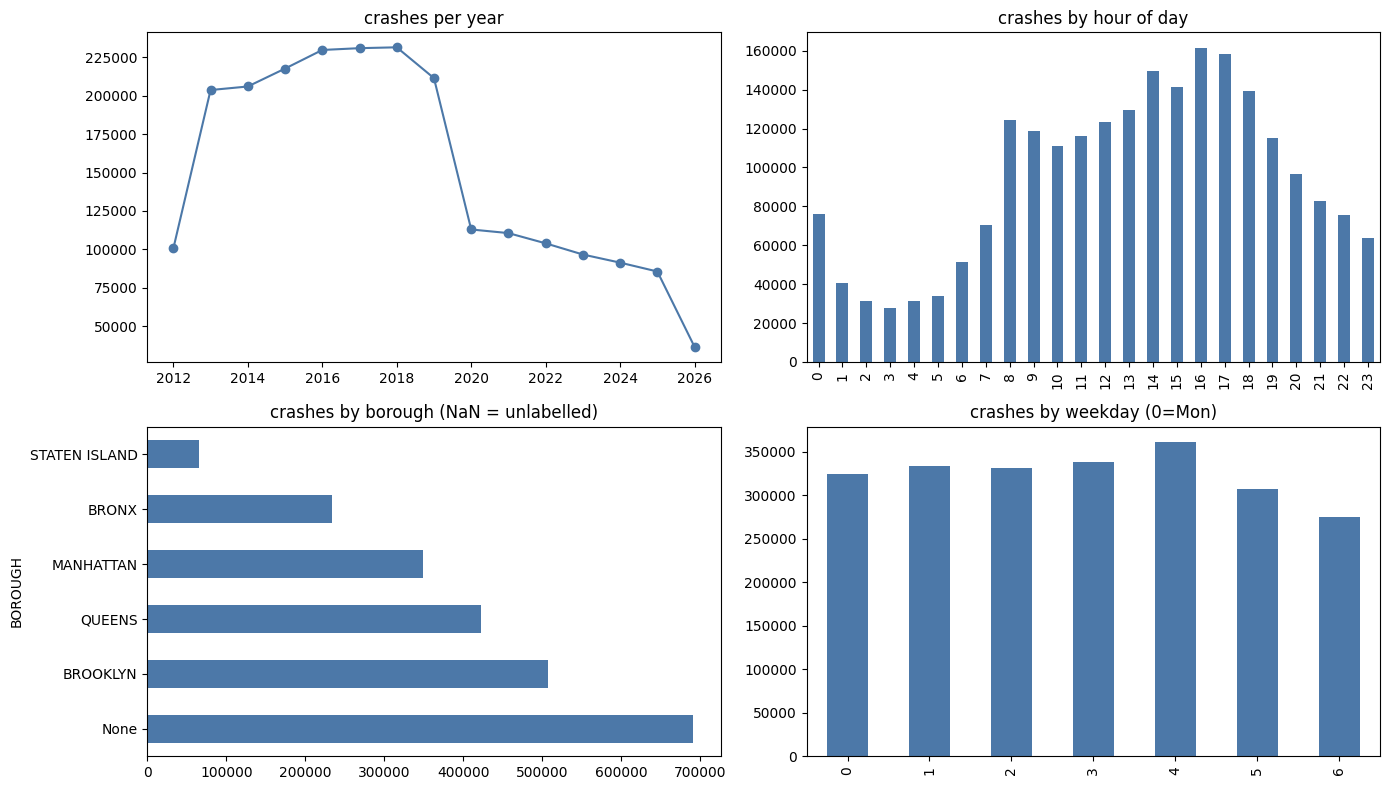

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))

df.groupby("year").size().plot(ax=ax[0, 0], marker="o", color="#4C78A8")
ax[0, 0].set_title("crashes per year")

df.groupby("hour").size().plot.bar(ax=ax[0, 1], color="#4C78A8")
ax[0, 1].set_title("crashes by hour of day")

df["BOROUGH"].value_counts(dropna=False).plot.barh(ax=ax[1, 0], color="#4C78A8")
ax[1, 0].set_title("crashes by borough (NaN = unlabelled)")

df.groupby("dow").size().plot.bar(ax=ax[1, 1], color="#4C78A8")
ax[1, 1].set_title("crashes by weekday (0=Mon)")

for a in ax.ravel():
    a.set_xlabel("")
plt.tight_layout()
plt.show()

usable coords: 2,020,641 / 2,269,187 (89.0%)
  NaN lat/lon      : 240,806
  exactly 0.0      : 7,591


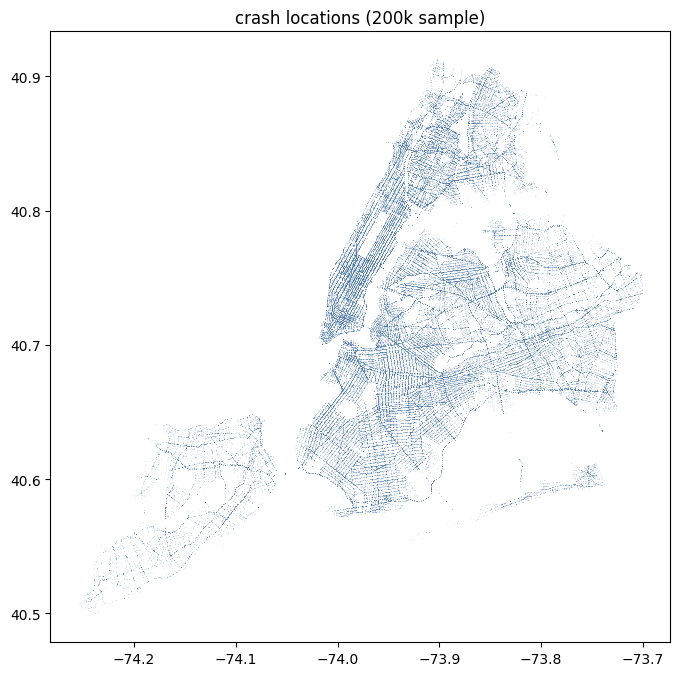

In [12]:
# Geo: (0, 0) sentinels must be dropped, not just NaNs
geo = df[(df.LATITUDE.between(40.4, 41.0)) & (df.LONGITUDE.between(-74.3, -73.6))]
print(f"usable coords: {len(geo):,} / {len(df):,} ({len(geo) / len(df) * 100:.1f}%)")
print(f"  NaN lat/lon      : {df.LATITUDE.isna().sum():,}")
print(f"  exactly 0.0      : {(df.LATITUDE == 0).sum():,}")

s = geo.sample(min(200_000, len(geo)), random_state=0)
plt.figure(figsize=(8, 9))
plt.scatter(s.LONGITUDE, s.LATITUDE, s=0.3, alpha=0.15, color="#4C78A8", linewidths=0)
plt.gca().set_aspect(1 / np.cos(np.radians(40.7)))
plt.title("crash locations (200k sample)")
plt.show()